# Interactive particle trajectory point selector

This notebook loads a trajectory CSV, visualizes the particle path, lets you interactively select points of interest, and exports the selected **frame + coordinates** to CSV.

Expected CSV columns for your current file:

- `Frame`
- `Longitudinal_From_Special`
- `Transverse_Dist`

The code is written so you can easily change the column names if future trajectory CSVs use a different format.

## 1. Install/import required packages

`ipywidgets` and `%matplotlib widget` provide the interactive plotting. If the interactive figure does not show, install `ipympl` and restart the notebook kernel.

In [2]:
# If needed, uncomment this line and run once:
# %pip install ipympl ipywidgets pandas matplotlib numpy

%matplotlib widget

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import tkinter as tk
from tkinter import filedialog


## 2. Load trajectory CSV

Change `csv_path` if your file is somewhere else. For a batch of trajectory files, you can point this to any similar CSV.

In [10]:
# Open file picker to select trajectory CSV
root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

selected_file = filedialog.askopenfilename(
    title="Select trajectory CSV file",
    filetypes=[
        ("CSV files", "*.csv"),
        ("All files", "*.*")
    ]
)

root.destroy()

if not selected_file:
    raise FileNotFoundError("No CSV file selected.")

csv_path = Path(selected_file)

print(f"Selected file: {csv_path}")

# If the CSV is not in the same folder as this notebook, use an absolute path, for example:
# csv_path = Path(r"C:/Users/YourName/Desktop/trajectory_249.csv")

df = pd.read_csv(csv_path)

print(f"Loaded: {csv_path}")
print(f"Shape: {df.shape}")
display(df.head())
print("Columns:", list(df.columns))


Selected file: D:\Dharaneeswar\data\3-2 Masks\144-482\trajectory_144-482.csv
Loaded: D:\Dharaneeswar\data\3-2 Masks\144-482\trajectory_144-482.csv
Shape: (339, 5)


,Frame,Longitudinal_From_Special,Transverse_Dist,Special_Node_X,Special_Node_Y
0,144,-285.027136,5.963380,291.219039,210.911692
1,145,-244.864354,4.159034,291.701411,211.746845
2,146,-171.572310,2.199925,290.611895,213.361291
3,147,-110.040385,2.103034,290.570714,214.827446
4,148,-55.710487,2.863235,288.107828,217.560361


Columns: ['Frame', 'Longitudinal_From_Special', 'Transverse_Dist', 'Special_Node_X', 'Special_Node_Y']


## 3. Configure trajectory columns

For your uploaded CSV, the x/y coordinates are:

- x-axis: `Longitudinal_From_Special`
- y-axis: `Transverse_Dist`

The frame column is `Frame`.

In [11]:
# ---- Column settings ----
frame_col = "Frame"
x_col = "Longitudinal_From_Special"
y_col = "Transverse_Dist"
center_pt_x = "Special_Node_X"
center_pt_y = "Special_Node_Y"

# Optional: if you later have multiple tracks in one file, set this to the track-id column name.
# For your current CSV, there is only one trajectory, so keep it as None.
track_col = None

required_cols = [frame_col, x_col, y_col, center_pt_x, center_pt_y]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns: {list(df.columns)}")

# Clean and sort
plot_df = df.copy()
plot_df = plot_df.dropna(subset=required_cols).sort_values(frame_col).reset_index(drop=True)

# Add a default trajectory ID if the file contains only one trajectory
if track_col is None:
    plot_df["Trajectory_ID"] = 0
    track_col_for_plot = "Trajectory_ID"
else:
    track_col_for_plot = track_col

print(f"Frame range: {plot_df[frame_col].min()} to {plot_df[frame_col].max()}")
print(f"Number of points: {len(plot_df)}")
print(f"Number of trajectories: {plot_df[track_col_for_plot].nunique()}")
display(plot_df.head())


Frame range: 144 to 482
Number of points: 339
Number of trajectories: 1


,Frame,Longitudinal_From_Special,Transverse_Dist,Special_Node_X,Special_Node_Y,Trajectory_ID
0,144,-285.027136,5.963380,291.219039,210.911692,0
1,145,-244.864354,4.159034,291.701411,211.746845,0
2,146,-171.572310,2.199925,290.611895,213.361291,0
3,147,-110.040385,2.103034,290.570714,214.827446,0
4,148,-55.710487,2.863235,288.107828,217.560361,0


## 4. Quick static overview

This gives a first look at the trajectory shape. The line shows movement order, and points are colored by frame.

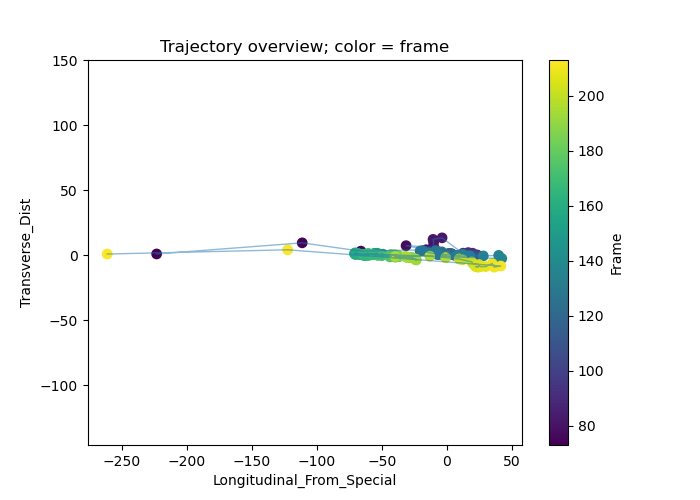

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

for tid, g in plot_df.groupby(track_col_for_plot):
    ax.plot(g[x_col], g[y_col], alpha=0.5, linewidth=1)

sc = ax.scatter(plot_df[x_col], plot_df[y_col], c=plot_df[frame_col], s=45)
ax.set_xlabel(x_col)
ax.set_ylabel(y_col)
ax.set_title("Trajectory overview; color = frame")
ax.axis("equal")
fig.colorbar(sc, ax=ax, label=frame_col)
plt.show()


## 5. Interactive point-of-interest selector

How to use:

1. Run the cell below.
2. Select a trajectory ID if your file contains multiple tracks.
3. Drag the frame range slider to focus on part of the trajectory.
4. Click a point on the plot.
5. Press **Add nearest point** to save the closest trajectory point.
6. Repeat for more points.
7. Press **Export selected points** to save the selected frame and coordinates.

The exported table contains:

- selected row index
- frame
- x coordinate
- y coordinate
- trajectory ID
- optional label

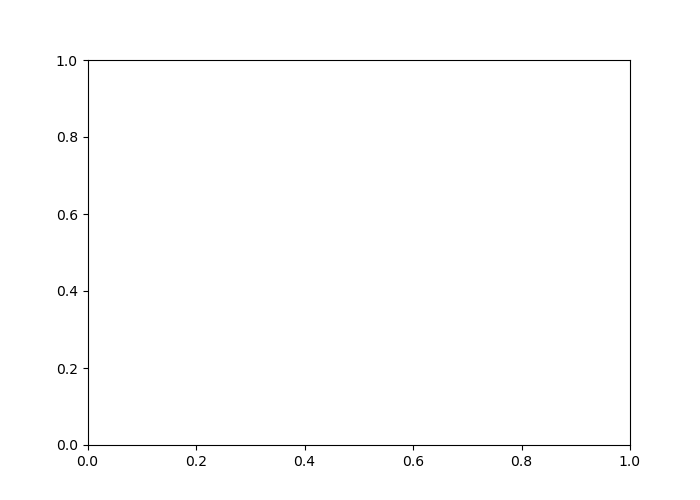

In [ ]:
# Interactive trajectory point selector

selected_points = []
last_clicked = {"x": None, "y": None, "nearest_idx": None}

# Widgets
trajectory_ids = sorted(plot_df[track_col_for_plot].dropna().unique().tolist())
track_dropdown = widgets.Dropdown(
    options=trajectory_ids,
    value=trajectory_ids[0],
    description="Track:",
    disabled=(len(trajectory_ids) == 1),
)

frame_min = int(plot_df[frame_col].min())
frame_max = int(plot_df[frame_col].max())
frame_slider = widgets.IntRangeSlider(
    value=[frame_min, frame_max],
    min=frame_min,
    max=frame_max,
    step=1,
    description="Frames:",
    continuous_update=False,
    layout=widgets.Layout(width="650px")
)

label_text = widgets.Text(
    value="",
    placeholder="optional label, e.g. turn_start / peak / end",
    description="Label:",
    layout=widgets.Layout(width="450px")
)

add_button = widgets.Button(description="Add nearest point", button_style="success")
undo_button = widgets.Button(description="Undo last", button_style="warning")
clear_button = widgets.Button(description="Clear all", button_style="danger")
export_button = widgets.Button(description="Export selected points", button_style="primary")

export_name = widgets.Text(
    value="selected_trajectory_points.csv",
    description="Export as:",
    layout=widgets.Layout(width="450px")
)

status = widgets.Output()
table_out = widgets.Output()

fig, ax = plt.subplots(figsize=(7, 5))
plt.show()


def get_filtered_df():
    f0, f1 = frame_slider.value
    mask = (
        (plot_df[track_col_for_plot] == track_dropdown.value)
        & (plot_df[frame_col] >= f0)
        & (plot_df[frame_col] <= f1)
    )
    return plot_df.loc[mask].copy()


def redraw():
    ax.clear()
    g = get_filtered_df()
    if len(g) == 0:
        ax.set_title("No points in current frame range")
        fig.canvas.draw_idle()
        return

    ax.plot(g[x_col], g[y_col], alpha=0.5, linewidth=1)
    ax.scatter(g[x_col], g[y_col], c=g[frame_col], s=45, picker=True)

    # Mark selected points from the same trajectory/range
    if selected_points:
        sel_df = pd.DataFrame(selected_points)
        f0, f1 = frame_slider.value
        sel_mask = (
            (sel_df[track_col_for_plot] == track_dropdown.value)
            & (sel_df[frame_col] >= f0)
            & (sel_df[frame_col] <= f1)
        )
        visible_sel = sel_df.loc[sel_mask]
        if len(visible_sel):
            ax.scatter(visible_sel[x_col], visible_sel[y_col], s=140, marker="x", linewidths=2)
            for _, row in visible_sel.iterrows():
                txt = str(row.get("label", "")) if row.get("label", "") else str(row[frame_col])
                ax.annotate(txt, (row[x_col], row[y_col]), xytext=(5, 5), textcoords="offset points")

    # Mark nearest point after click
    if last_clicked["nearest_idx"] is not None and last_clicked["nearest_idx"] in g.index:
        row = plot_df.loc[last_clicked["nearest_idx"]]
        ax.scatter([row[x_col]], [row[y_col]], s=180, marker="o", facecolors="none", linewidths=2)

    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title("Click near a point, then press 'Add nearest point'")
    ax.axis("equal")
    fig.canvas.draw_idle()


def refresh_table():
    with table_out:
        clear_output(wait=True)
        if not selected_points:
            print("No selected points yet.")
        else:
            display(pd.DataFrame(selected_points))


def find_nearest_point(x_click, y_click):
    g = get_filtered_df()
    if len(g) == 0:
        return None

    # Normalize distance by axis range so x/y scale differences do not dominate too much.
    x_range = max(g[x_col].max() - g[x_col].min(), 1e-9)
    y_range = max(g[y_col].max() - g[y_col].min(), 1e-9)
    dist2 = ((g[x_col] - x_click) / x_range) ** 2 + ((g[y_col] - y_click) / y_range) ** 2
    return int(dist2.idxmin())


def on_click(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return
    idx = find_nearest_point(event.xdata, event.ydata)
    last_clicked["x"] = event.xdata
    last_clicked["y"] = event.ydata
    last_clicked["nearest_idx"] = idx
    with status:
        clear_output(wait=True)
        if idx is not None:
            row = plot_df.loc[idx]
            print(
                f"Nearest point selected for preview: "
                f"index={idx}, frame={row[frame_col]}, "
                f"x={row[x_col]:.3f}, y={row[y_col]:.3f}"
            )
    redraw()


def add_nearest(_):
    idx = last_clicked["nearest_idx"]
    with status:
        clear_output(wait=True)
        if idx is None:
            print("Click near a trajectory point first.")
            return
        row = plot_df.loc[idx]
        record = {
            "source_csv": str(csv_path),
            "row_index": idx,
            track_col_for_plot: row[track_col_for_plot],
            frame_col: row[frame_col],
            x_col: row[x_col],
            y_col: row[y_col],
            center_pt_x: row[center_pt_x],
            center_pt_y: row[center_pt_y],
            "label": label_text.value.strip(),
        }
        selected_points.append(record)
        print(f"Added: frame={row[frame_col]}, x={row[x_col]:.3f}, y={row[y_col]:.3f}")
    label_text.value = ""
    refresh_table()
    redraw()


def undo_last(_):
    with status:
        clear_output(wait=True)
        if selected_points:
            removed = selected_points.pop()
            print(f"Removed last selection: frame={removed[frame_col]}")
        else:
            print("No selected points to undo.")
    refresh_table()
    redraw()


def clear_all(_):
    selected_points.clear()
    last_clicked["nearest_idx"] = None
    with status:
        clear_output(wait=True)
        print("Cleared all selected points.")
    refresh_table()
    redraw()


def export_selected(_):
    with status:
        clear_output(wait=True)
        if not selected_points:
            print("No selected points to export.")
            return
        out_path = Path(export_name.value)
        pd.DataFrame(selected_points).to_csv(out_path, index=False)
        print(f"Exported {len(selected_points)} selected point(s) to: {out_path.resolve()}")


fig.canvas.mpl_connect("button_press_event", on_click)
add_button.on_click(add_nearest)
undo_button.on_click(undo_last)
clear_button.on_click(clear_all)
export_button.on_click(export_selected)
track_dropdown.observe(lambda change: redraw(), names="value")
frame_slider.observe(lambda change: redraw(), names="value")

controls = widgets.VBox([
    widgets.HBox([track_dropdown]),
    frame_slider,
    label_text,
    widgets.HBox([add_button, undo_button, clear_button]),
    widgets.HBox([export_name, export_button]),
    status,
    table_out,
])

display(controls)
refresh_table()
redraw()


## Export selected points in two steps

### Part 1 — Add current selections to a cumulative dataframe

Run this after selecting points from the current trajectory CSV.  
It appends the current `selected_points` into `all_selected_points_df` and records the source CSV filename.

After running this part, `selected_points` is cleared to avoid accidentally adding the same points twice.

### Part 2 — Export all selected points

Run this only after finishing selection across all desired trajectory CSV files.  
It exports the cumulative dataframe `all_selected_points_df` to:

`all_selected_points_only.csv`

This export contains only the exact selected points, not any surrounding frame window.

In [19]:
#clear the all_selected_points_df if needed:
all_selected_points_df = pd.DataFrame()
# all_selected_points_df = all_selected_points_df.drop_duplicates()


In [20]:
#show current selected points
all_selected_points_df

""


In [52]:
# Part 1: Add current selected points into a cumulative dataframe

if "all_selected_points_df" not in globals():
    all_selected_points_df = pd.DataFrame()

if selected_points:
    current_selected_df = pd.DataFrame(selected_points).copy()

    # Optional but strongly recommended:
    # record which CSV file these selected points came from
    current_selected_df["source_file"] = Path(csv_path).name

    all_selected_points_df = pd.concat(
        [all_selected_points_df, current_selected_df],
        ignore_index=True
    )

    print(f"Added {len(current_selected_df)} selected points from {Path(csv_path).name}")
    print(f"Total selected points so far: {len(all_selected_points_df)}")

    display(all_selected_points_df)

    # Optional: clear selected_points after adding,
    # so the same points are not added again accidentally
    selected_points.clear()

else:
    print("No selected points yet. Run the selector above first.")

Added 2 selected points from trajectory_304-524.csv
Total selected points so far: 12


,source_csv,row_index,Trajectory_ID,Frame,Longitudinal_From_Special,Transverse_Dist,label,source_file
0,D:\Dharaneeswar\data\1-1 Masks\498-579\traject...,75,0.0,573.0,9.077445,-32.170356,,trajectory.csv
1,D:\Dharaneeswar\data\1-1 Masks\854-1085\trajec...,16,0.0,870.0,-43.675925,-23.647637,,trajectory.csv
2,D:\Dharaneeswar\data\1-1 Masks\854-1085\trajec...,74,0.0,928.0,-45.487043,-6.471784,,trajectory.csv
3,D:\Dharaneeswar\data\2-1 Masks\129-471\traject...,19,0.0,148.0,-44.883615,-12.073589,,trajectory_129.csv
4,D:\Dharaneeswar\data\3-1 Masks\100-293\traject...,22,0.0,122.0,63.463989,-1.021478,,trajectory_100.csv
5,D:\Dharaneeswar\data\3-2 Masks\144-482\traject...,29,0.0,173.0,28.956511,-0.132106,,trajectory_144.csv
6,D:\Dharaneeswar\data\3-2 Masks\144-482\traject...,132,0.0,276.0,59.133948,3.489413,,trajectory_144.csv
7,D:\Dharaneeswar\data\3-2 Masks\144-482\traject...,247,0.0,391.0,53.627335,-1.550655,,trajectory_144.csv
8,D:\Dharaneeswar\data\3-3 Masks\particle_1\traj...,11,0.0,88.0,8.338262,-0.372021,,trajectory_73-213.csv
9,D:\Dharaneeswar\data\3-3 Masks\particle_1\traj...,61,0.0,138.0,26.710588,-2.555372,,trajectory_73-213.csv


In [53]:
# Part 2: Export the cumulative selected points dataframe

if "all_selected_points_df" in globals() and len(all_selected_points_df) > 0:
    point_out = Path("all_selected_points_only.csv")
    all_selected_points_df.to_csv(point_out, index=False)

    print(f"Exported all selected points to: {point_out.resolve()}")
    display(all_selected_points_df)

else:
    print("No cumulative selected points found yet. Run Part 1 after selecting points first.")

Exported all selected points to: D:\Dharaneeswar\sam2GUI_DD\all_selected_points_only.csv


,source_csv,row_index,Trajectory_ID,Frame,Longitudinal_From_Special,Transverse_Dist,label,source_file
0,D:\Dharaneeswar\data\1-1 Masks\498-579\traject...,75,0.0,573.0,9.077445,-32.170356,,trajectory.csv
1,D:\Dharaneeswar\data\1-1 Masks\854-1085\trajec...,16,0.0,870.0,-43.675925,-23.647637,,trajectory.csv
2,D:\Dharaneeswar\data\1-1 Masks\854-1085\trajec...,74,0.0,928.0,-45.487043,-6.471784,,trajectory.csv
3,D:\Dharaneeswar\data\2-1 Masks\129-471\traject...,19,0.0,148.0,-44.883615,-12.073589,,trajectory_129.csv
4,D:\Dharaneeswar\data\3-1 Masks\100-293\traject...,22,0.0,122.0,63.463989,-1.021478,,trajectory_100.csv
5,D:\Dharaneeswar\data\3-2 Masks\144-482\traject...,29,0.0,173.0,28.956511,-0.132106,,trajectory_144.csv
6,D:\Dharaneeswar\data\3-2 Masks\144-482\traject...,132,0.0,276.0,59.133948,3.489413,,trajectory_144.csv
7,D:\Dharaneeswar\data\3-2 Masks\144-482\traject...,247,0.0,391.0,53.627335,-1.550655,,trajectory_144.csv
8,D:\Dharaneeswar\data\3-3 Masks\particle_1\traj...,11,0.0,88.0,8.338262,-0.372021,,trajectory_73-213.csv
9,D:\Dharaneeswar\data\3-3 Masks\particle_1\traj...,61,0.0,138.0,26.710588,-2.555372,,trajectory_73-213.csv


For only one point output:

In [11]:
if selected_points:
    selected_df = pd.DataFrame(selected_points).copy()

    point_out = Path("selected_points_only.csv")
    selected_df.to_csv(point_out, index=False)

    print(f"Exported selected points to: {point_out.resolve()}")
    display(selected_df)
else:
    print("No selected points yet. Run the selector above first.")

Exported selected points to: D:\Dharaneeswar\sam2GUI_DD\selected_points_only.csv


,source_csv,row_index,Trajectory_ID,Frame,Longitudinal_From_Special,Transverse_Dist,label
0,D:\Dharaneeswar\data\1-1 Masks\498-579\traject...,75,0.0,573.0,9.077445,-32.170356,


## 7. Optional: save a figure with selected points annotated

Run this after selecting points if you want a PNG record of the chosen points.

Saved figure to: D:\Dharaneeswar\sam2GUI_DD\selected_trajectory_points.png


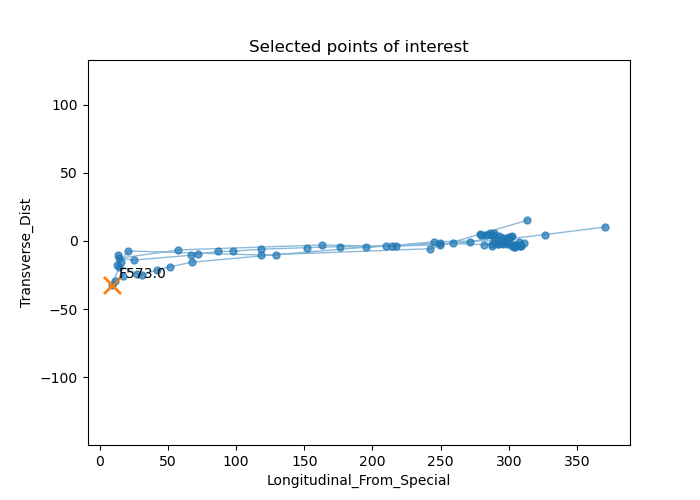

In [10]:
if selected_points:
    selected_df = pd.DataFrame(selected_points)

    fig2, ax2 = plt.subplots(figsize=(7, 5))
    for tid, g in plot_df.groupby(track_col_for_plot):
        ax2.plot(g[x_col], g[y_col], alpha=0.5, linewidth=1)
        ax2.scatter(g[x_col], g[y_col], s=25, alpha=0.7)

    ax2.scatter(selected_df[x_col], selected_df[y_col], s=150, marker="x", linewidths=2)
    for _, row in selected_df.iterrows():
        label = row["label"] if row["label"] else f"F{row[frame_col]}"
        ax2.annotate(label, (row[x_col], row[y_col]), xytext=(5, 5), textcoords="offset points")

    ax2.set_xlabel(x_col)
    ax2.set_ylabel(y_col)
    ax2.set_title("Selected points of interest")
    ax2.axis("equal")

    figure_out = Path("selected_trajectory_points.png")
    fig2.savefig(figure_out, dpi=300, bbox_inches="tight")
    print(f"Saved figure to: {figure_out.resolve()}")
    plt.show()
else:
    print("No selected points yet. Run the selector above first.")
